# Final Recommended Model Comparison

This notebook implements BaselineOnly, User-kNN, , Item-kNN, SVD, SVD++, LightGCN, NCF models. These models are regarded as baseline model and most promising model is selected to further optimize its performance by tuning hyperparameters. All results are compared based on following performance metrics:
- RMSE
- MAE
- Precision@10

For more information about the work, read related study.

## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.sparse as sparse
import torch.optim as optim
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
from surprise import BaselineOnly, KNNBasic, SVD, SVDpp, Dataset as SurpriseDataset, Reader, accuracy
from surprise.model_selection import cross_validate
import optuna
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
import time

# Metrics Storage
results = []

/home/msi/bil573-project/project/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Utility Functions

In [2]:
def calculate_precision_at_10(predictions_df):
    precisions = []
    user_groups = predictions_df.groupby('UserIdx')
    for u, group in user_groups:
        top_10 = group.sort_values(by='Prediction', ascending=False).head(10)
        relevant = (top_10['Rating'] >= 4).sum()
        precisions.append(relevant / 10.0)
    return np.mean(precisions) if precisions else 0.0

def evaluate_metrics(name, test_df, predictions, train_time=0.0):
    rmse = np.sqrt(mean_squared_error(test_df['Rating'], predictions))
    mae = mean_absolute_error(test_df['Rating'], predictions)
    eval_df = test_df.copy()
    eval_df['Prediction'] = predictions
    p10 = calculate_precision_at_10(eval_df)
    print(f"[{name}] RMSE: {rmse:.4f} | MAE: {mae:.4f} | Precision@10: {p10:.4f} | Time: {train_time:.2f}s")
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'Precision@10': p10, 'TrainTime': train_time})
    return rmse, mae, p10

## 3. Preprocessing Dataset 

In [3]:
print("Loading unified dataset...")
# Load Ratings
rating_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
ratings_df = pd.read_csv('../dataset/ratings.dat', sep='::', names=rating_cols, engine='python', encoding='ISO-8859-1')

# Map UserID and MovieID to contiguous integers
user2idx = {o:i for i,o in enumerate(ratings_df['UserID'].unique())}
item2idx = {o:i for i,o in enumerate(ratings_df['MovieID'].unique())}

ratings_df['UserIdx'] = ratings_df['UserID'].map(user2idx)
ratings_df['ItemIdx'] = ratings_df['MovieID'].map(item2idx)

num_users = len(user2idx)
num_items = len(item2idx)

# Unified Data Split
train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)

print(f"Total Users: {num_users}, Total Items: {num_items}")
print(f"Train Shape: {train_df.shape}, Test Shape: {test_df.shape}")

# Prepare Surprise data format
reader = Reader(rating_scale=(1, 5))
train_surprise = SurpriseDataset.load_from_df(train_df[['UserIdx', 'ItemIdx', 'Rating']], reader).build_full_trainset()
test_surprise = list(test_df[['UserIdx', 'ItemIdx', 'Rating']].itertuples(index=False, name=None))



Loading unified dataset...
Total Users: 6040, Total Items: 3706
Train Shape: (800167, 6), Test Shape: (200042, 6)


## 4. Baseline Models

### 4.1 BaselineOnly

It is statistical model that predicts ratings according to average rating per movie.

In [4]:
print("\n--- Training BaselineOnly ---")
start = time.time()
algo_bl = BaselineOnly(bsl_options={'method': 'als'})
algo_bl.fit(train_surprise)
train_time = time.time() - start
bl_preds = [pred.est for pred in algo_bl.test(test_surprise)]
evaluate_metrics("BaselineOnly", test_df, bl_preds, train_time)


--- Training BaselineOnly ---
Estimating biases using als...
[BaselineOnly] RMSE: 0.9122 | MAE: 0.7231 | Precision@10: 0.6650 | Time: 1.96s


(0.9122494384933382, 0.7231266919629927, 0.6649884067572044)

### 4.2 Collaborative Filtering (CF)

#### 4.2.1 Memory Based CF

##### 4.2.1.1 User kNN

In [5]:
print("\n--- Training User kNN ---")
start = time.time()
# Using cosine to speed up over pearson, limit max_k to 20 to speed up even more
algo_uknn = KNNBasic(k=20, sim_options={'user_based': True, 'name': 'cosine'})
algo_uknn.fit(train_surprise)
train_time = time.time() - start
uknn_preds = [pred.est for pred in algo_uknn.test(test_surprise)]
evaluate_metrics("User kNN", test_df, uknn_preds, train_time)


--- Training User kNN ---
Computing the cosine similarity matrix...
Done computing similarity matrix.
[User kNN] RMSE: 0.9915 | MAE: 0.7837 | Precision@10: 0.6568 | Time: 37.76s


(0.991510188884877, 0.7836661912938503, 0.6568068896985757)

##### 4.2.1.2 Item kNN

In [6]:
print("\n--- Training Item kNN ---")
start = time.time()
algo_iknn = KNNBasic(k=20, sim_options={'user_based': False, 'name': 'cosine'})
algo_iknn.fit(train_surprise)
train_time = time.time() - start
iknn_preds = [pred.est for pred in algo_iknn.test(test_surprise)]
evaluate_metrics("Item kNN", test_df, iknn_preds, train_time)


--- Training Item kNN ---
Computing the cosine similarity matrix...
Done computing similarity matrix.
[Item kNN] RMSE: 1.0122 | MAE: 0.7895 | Precision@10: 0.6528 | Time: 14.50s


(1.0122281675147116, 0.789511846592176, 0.6528320635972177)

#### 4.2.2 Model Based CF

#### 4.2.2.1 Pure SVD

In [7]:
print("\n--- Training Pure SVD ---")
start = time.time()
algo_svd = SVD(random_state=42)
algo_svd.fit(train_surprise)
train_time = time.time() - start
svd_preds = [pred.est for pred in algo_svd.test(test_surprise)]
evaluate_metrics("Pure SVD", test_df, svd_preds, train_time)


--- Training Pure SVD ---
[Pure SVD] RMSE: 0.8784 | MAE: 0.6902 | Precision@10: 0.6816 | Time: 10.57s


(0.8783851612324959, 0.6902116038110034, 0.681616429281219)

#### 4.2.2.2 SVD++

In [8]:
print("\n--- Training SVD++ ---")
start = time.time()
# Keep epochs low for runtime
algo_svdpp = SVDpp(n_epochs=10, random_state=42)
algo_svdpp.fit(train_surprise)
train_time = time.time() - start
svdpp_preds = [pred.est for pred in algo_svdpp.test(test_surprise)]
evaluate_metrics("SVD++", test_df, svdpp_preds, train_time)


--- Training SVD++ ---
[SVD++] RMSE: 0.8736 | MAE: 0.6867 | Precision@10: 0.6831 | Time: 232.00s


(0.8735728152333482, 0.6866872875749362, 0.6831069890692283)

#### 4.2.2.3 Neural Collaborative Filtering (NCF)

In [9]:
print("\n--- Training NCF ---")
class MovieLensDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['UserIdx'].values, dtype=torch.long)
        self.items = torch.tensor(df['ItemIdx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['Rating'].values, dtype=torch.float32)
    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx): return self.users[idx], self.items[idx], self.ratings[idx]

class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, mf_dim=8, layers=[64, 32, 16, 8]):
        super(NeuMF, self).__init__()
        self.embedding_user_mf = nn.Embedding(num_embeddings=num_users, embedding_dim=mf_dim)
        self.embedding_item_mf = nn.Embedding(num_embeddings=num_items, embedding_dim=mf_dim)
        mlp_dim = layers[0] // 2
        self.embedding_user_mlp = nn.Embedding(num_embeddings=num_users, embedding_dim=mlp_dim)
        self.embedding_item_mlp = nn.Embedding(num_embeddings=num_items, embedding_dim=mlp_dim)
        self.fc_layers = nn.ModuleList()
        for in_size, out_size in zip(layers[:-1], layers[1:]):
            self.fc_layers.append(nn.Linear(in_size, out_size))
            self.fc_layers.append(nn.ReLU())
        self.affine_output = nn.Linear(in_features=layers[-1] + mf_dim, out_features=1)
        
    def forward(self, user_indices, item_indices):
        user_embedding_mf = self.embedding_user_mf(user_indices)
        item_embedding_mf = self.embedding_item_mf(item_indices)
        mf_vector = torch.mul(user_embedding_mf, item_embedding_mf)
        
        user_embedding_mlp = self.embedding_user_mlp(user_indices)
        item_embedding_mlp = self.embedding_item_mlp(item_indices)
        mlp_vector = torch.cat([user_embedding_mlp, item_embedding_mlp], dim=-1)
        
        for m in self.fc_layers:
            mlp_vector = m(mlp_vector)
            
        predict_vector = torch.cat([mf_vector, mlp_vector], dim=-1)
        return self.affine_output(predict_vector).squeeze()

train_loader = DataLoader(MovieLensDataset(train_df), batch_size=512, shuffle=True)
test_loader = DataLoader(MovieLensDataset(test_df), batch_size=512, shuffle=False)

ncf_model = NeuMF(num_users, num_items)
criterion = nn.MSELoss()
optimizer = optim.Adam(ncf_model.parameters(), lr=0.001)

# Keep epochs reasonably low for standard execution
ncf_epochs = 5 
start = time.time()
for epoch in range(ncf_epochs):
    ncf_model.train()
    total_loss = 0
    for users, items, ratings in train_loader:
        optimizer.zero_grad()
        predictions = ncf_model(users, items)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"NCF Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")
train_time = time.time() - start

ncf_model.eval()
ncf_preds = []
with torch.no_grad():
    for users, items, _ in test_loader:
        preds = ncf_model(users, items)
        ncf_preds.extend(preds.numpy())
evaluate_metrics("NCF", test_df, ncf_preds, train_time)


--- Training NCF ---
NCF Epoch 1 Loss: 1.5397
NCF Epoch 2 Loss: 0.9036
NCF Epoch 3 Loss: 0.8472
NCF Epoch 4 Loss: 0.8262
NCF Epoch 5 Loss: 0.8147
[NCF] RMSE: 0.9223 | MAE: 0.7308 | Precision@10: 0.6604 | Time: 58.46s


(0.9223006304388129, 0.7308122927016065, 0.6604173567406426)

#### 4.2.2.4 LightGCN

In [10]:
print("\n--- Training LightGCN ---")
# Build Adjacency Matrix
R = sp.coo_matrix(
    (np.ones(len(train_df)), (train_df['UserIdx'].values, train_df['ItemIdx'].values)), 
    shape=(num_users, num_items)
).tolil()

A = sp.dok_matrix((num_users + num_items, num_users + num_items), dtype=np.float32)
A = A.tolil()
A[:num_users, num_users:] = R
A[num_users:, :num_users] = R.T

rowsum = np.array(A.sum(axis=1))
d_inv = np.power(rowsum, -0.5).flatten()
d_inv[np.isinf(d_inv)] = 0.
d_mat_inv = sp.diags(d_inv)
norm_adj = d_mat_inv.dot(A).dot(d_mat_inv).tocoo()

indices = torch.from_numpy(np.vstack((norm_adj.row, norm_adj.col)).astype(np.int64))
values = torch.from_numpy(norm_adj.data)
shape = torch.Size(norm_adj.shape)
norm_adj_tensor = torch.sparse_coo_tensor(indices, values, shape, dtype=torch.float32)

class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, num_layers=3, embedding_dim=64):
        super(LightGCN, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers
        self.user_embedding = nn.Embedding(num_embeddings=num_users, embedding_dim=embedding_dim)
        self.item_embedding = nn.Embedding(num_embeddings=num_items, embedding_dim=embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)
        
    def forward(self, norm_adj):
        ego_embeddings = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        all_embeddings = [ego_embeddings]
        for layer in range(self.num_layers):
            ego_embeddings = torch.sparse.mm(norm_adj, ego_embeddings)
            all_embeddings.append(ego_embeddings)
        all_embeddings = torch.stack(all_embeddings, dim=1)
        final_embeddings = torch.mean(all_embeddings, dim=1)
        users_emb, items_emb = torch.split(final_embeddings, [self.num_users, self.num_items])
        return users_emb, items_emb
        
    def predict(self, users_emb, items_emb, users, items):
        u_e = users_emb[users]
        i_e = items_emb[items]
        return torch.sum(u_e * i_e, dim=1) 

gcn_model = LightGCN(num_users, num_items)
gcn_optimizer = optim.Adam(gcn_model.parameters(), lr=0.01)
gcn_criterion = nn.MSELoss()

train_users = torch.tensor(train_df['UserIdx'].values, dtype=torch.long)
train_items = torch.tensor(train_df['ItemIdx'].values, dtype=torch.long)
train_ratings = torch.tensor(train_df['Rating'].values, dtype=torch.float32)

gcn_epochs = 10
start = time.time()
for epoch in range(gcn_epochs):
    gcn_model.train()
    gcn_optimizer.zero_grad()
    users_emb, items_emb = gcn_model(norm_adj_tensor)
    preds = gcn_model.predict(users_emb, items_emb, train_users, train_items)
    loss = gcn_criterion(preds, train_ratings)
    loss.backward()
    gcn_optimizer.step()
    if (epoch+1) % 2 == 0:
        print(f"LightGCN Epoch {epoch+1} Loss: {loss.item():.4f}")
train_time = time.time() - start

gcn_model.eval()
with torch.no_grad():
    users_emb, items_emb = gcn_model(norm_adj_tensor)
    test_users = torch.tensor(test_df['UserIdx'].values, dtype=torch.long)
    test_items = torch.tensor(test_df['ItemIdx'].values, dtype=torch.long)
    gcn_preds = gcn_model.predict(users_emb, items_emb, test_users, test_items).numpy()
evaluate_metrics("LightGCN", test_df, gcn_preds, train_time)


--- Training LightGCN ---


/tmp/ipykernel_13624/2020332163.py:14: RuntimeWarning: divide by zero encountered in power
  d_inv = np.power(rowsum, -0.5).flatten()


LightGCN Epoch 2 Loss: 14.0030
LightGCN Epoch 4 Loss: 13.6143
LightGCN Epoch 6 Loss: 12.8042
LightGCN Epoch 8 Loss: 11.5710
LightGCN Epoch 10 Loss: 9.9656
[LightGCN] RMSE: 3.0123 | MAE: 2.7962 | Precision@10: 0.6262 | Time: 7.73s


(3.0122521072900814, 2.7961933612823486, 0.6262172904935409)

### 4.3 Baseline Model Comparison

In [11]:
print("\n=== Baseline Model Comparison Results ===")
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='RMSE'))


=== Baseline Model Comparison Results ===


,Model,RMSE,MAE,Precision@10,TrainTime
4,SVD++,0.873573,0.686687,0.683107,231.997343
3,Pure SVD,0.878385,0.690212,0.681616,10.572464
0,BaselineOnly,0.912249,0.723127,0.664988,1.961065
5,NCF,0.922301,0.730812,0.660417,58.455237
1,User kNN,0.991510,0.783666,0.656807,37.762533
2,Item kNN,1.012228,0.789512,0.652832,14.497905
6,LightGCN,3.012252,2.796193,0.626217,7.731489


## 5. Proposed Method

From the result obtained in 4.4, SVD is selected for further optimization. Hyperparameter optimization is performed using Optuna Framework.

In [12]:
print("\n" + "="*70)
print("  SVD with Optuna Tuned")
print("="*70)

svd_tune_df = train_df[["UserIdx", "ItemIdx", "Rating"]].sample(frac=1, random_state=42)
svd_tune_data = SurpriseDataset.load_from_df(svd_tune_df, reader)

def objective_svd(trial):
    n_factors = trial.suggest_int("n_factors", 20, 200)
    n_epochs  = trial.suggest_int("n_epochs", 10, 40)
    lr_all    = trial.suggest_float("lr_all", 0.001, 0.05, log=True)
    reg_all   = trial.suggest_float("reg_all", 0.005, 0.3, log=True)

    algo = SVD(n_factors=n_factors, n_epochs=n_epochs,
              lr_all=lr_all, reg_all=reg_all, random_state=42)
    scores = cross_validate(algo, svd_tune_data, measures=["RMSE"], cv=3, n_jobs=-1)
    return scores["test_rmse"].mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_svd = optuna.create_study(direction="minimize",
                                 study_name="svd_broad_search")
study_svd.optimize(objective_svd, n_trials=30, show_progress_bar=True)
svd_best = study_svd.best_trial.params

# Train and evaluate the SVD-Optuna model
print("\nTraining SVD (Optuna-tuned) on full trainset...")
start = time.time()
algo_svd_optuna = SVD(
    n_factors=svd_best["n_factors"],
    n_epochs=svd_best["n_epochs"],
    lr_all=svd_best["lr_all"],
    reg_all=svd_best["reg_all"],
    random_state=42
)
algo_svd_optuna.fit(train_surprise)
train_time_svd = time.time() - start
svd_optuna_preds = [pred.est for pred in algo_svd_optuna.test(test_surprise)]
evaluate_metrics("Proposed Model", test_df, svd_optuna_preds, train_time_svd)


  SVD with Optuna Tuned


Best trial: 23. Best value: 0.873806: 100%|██████████| 30/30 [06:04<00:00, 12.14s/it]



Training SVD (Optuna-tuned) on full trainset...
[Proposed Model] RMSE: 0.8539 | MAE: 0.6740 | Precision@10: 0.6921 | Time: 18.88s


(0.853869867181846, 0.6740107344942365, 0.6921000331235508)

## 6. Final Model Comparison

In [13]:
print("\n=== Final Required Model Comparison Results ===")
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='RMSE'))


=== Final Required Model Comparison Results ===


,Model,RMSE,MAE,Precision@10,TrainTime
7,Proposed Model,0.853870,0.674011,0.692100,18.878066
4,SVD++,0.873573,0.686687,0.683107,231.997343
3,Pure SVD,0.878385,0.690212,0.681616,10.572464
0,BaselineOnly,0.912249,0.723127,0.664988,1.961065
5,NCF,0.922301,0.730812,0.660417,58.455237
1,User kNN,0.991510,0.783666,0.656807,37.762533
2,Item kNN,1.012228,0.789512,0.652832,14.497905
6,LightGCN,3.012252,2.796193,0.626217,7.731489


### 6.1 Visualization of Results


--- Visualizing Model Comparison ---


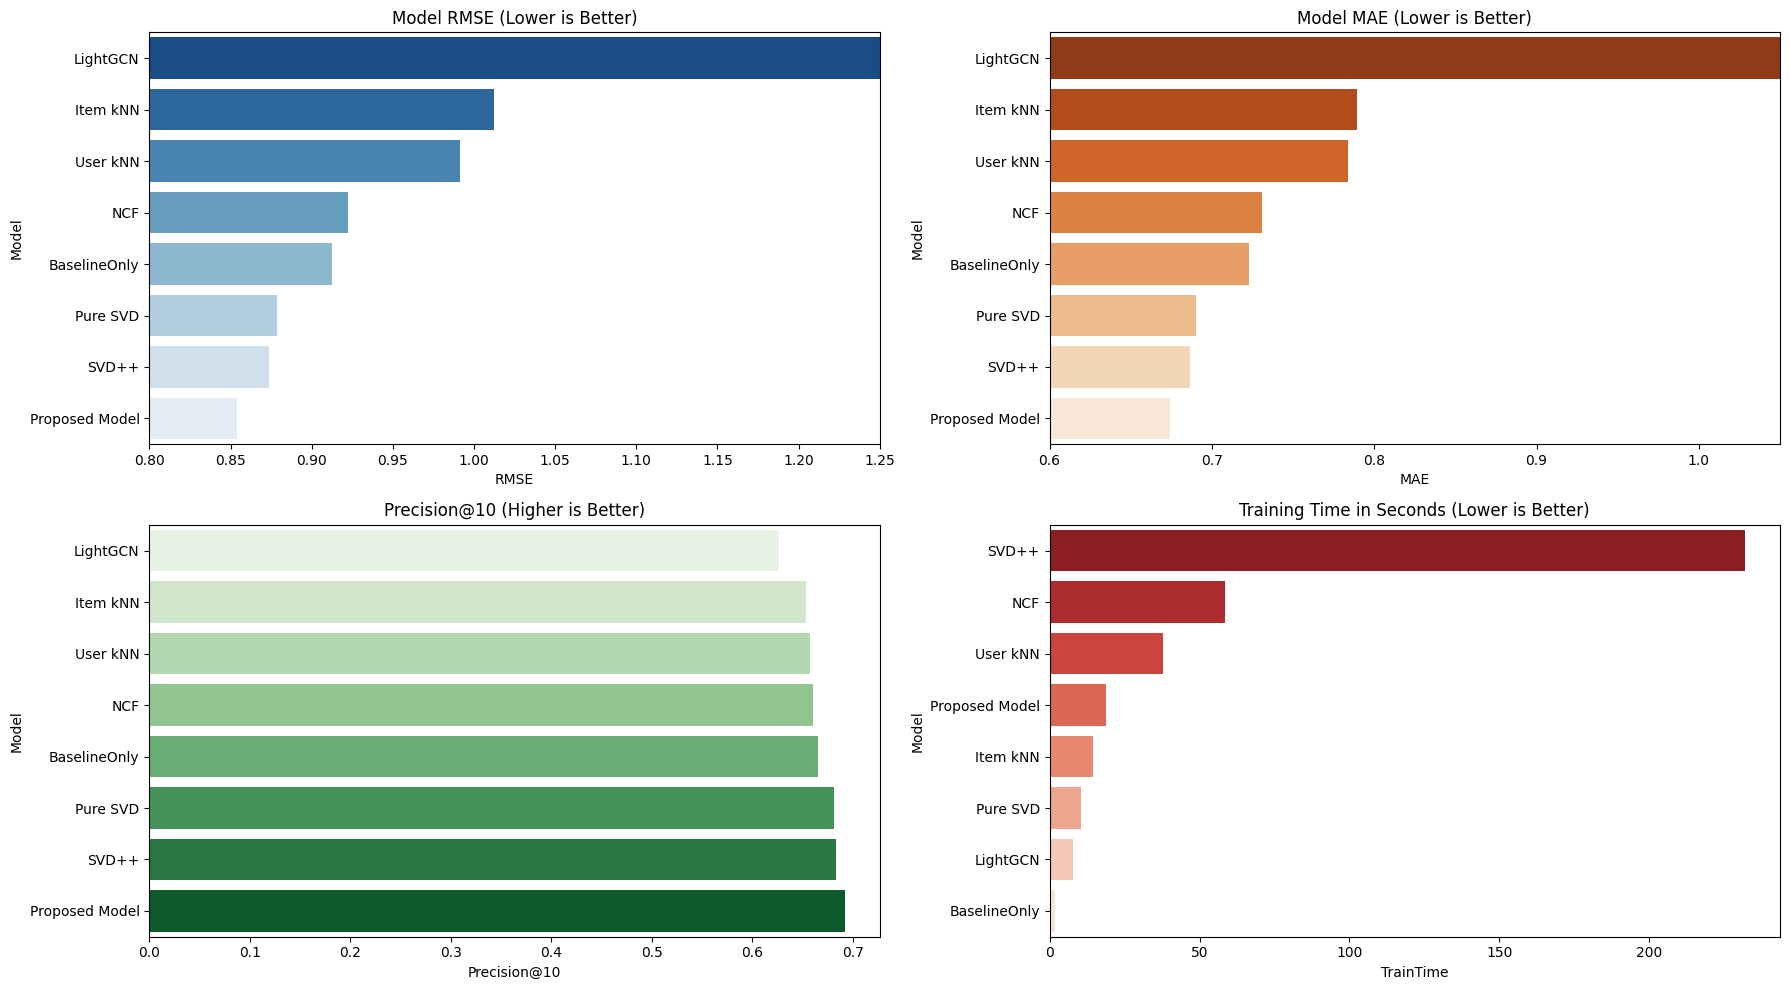

In [14]:
print("\n--- Visualizing Model Comparison ---")
import matplotlib.pyplot as plt
import seaborn as sns

if len(results_df) > 0:
    # Sort dataframe for clearer bar plots
    sorted_rmse = results_df.sort_values('RMSE', ascending=False)
    sorted_mae = results_df.sort_values('MAE', ascending=False)
    sorted_p10 = results_df.sort_values('Precision@10', ascending=True)
    sorted_time = results_df.sort_values('TrainTime', ascending=False)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    # Plot RMSE
    sns.barplot(x='RMSE', y='Model', data=sorted_rmse, ax=axes[0, 0], palette='Blues_r', hue='Model')
    axes[0, 0].set_title('Model RMSE (Lower is Better)')
    axes[0, 0].set_xlim(0.8, 1.25)  

    # Plot MAE
    sns.barplot(x='MAE', y='Model', data=sorted_mae, ax=axes[0, 1], palette='Oranges_r', hue='Model')
    axes[0, 1].set_title('Model MAE (Lower is Better)')
    axes[0, 1].set_xlim(0.6, 1.05) 

    # Plot Precision@10
    sns.barplot(x='Precision@10', y='Model', data=sorted_p10, ax=axes[1, 0], palette='Greens', hue='Model')
    axes[1, 0].set_title('Precision@10 (Higher is Better)')

    # Plot Training Time
    sns.barplot(x='TrainTime', y='Model', data=sorted_time, ax=axes[1, 1], palette='Reds_r', hue='Model')
    axes[1, 1].set_title('Training Time in Seconds (Lower is Better)')

    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")
